# CIFAR Ablation Report (W&B)

This notebook pulls the latest CIFAR ablation data from Weights & Biases and plots results per ablation axis.


In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "experiments" / "cifar").exists() and (p / "models").exists():
            return p
    raise RuntimeError("Could not locate repo root from current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
OUTPUT_DIR = REPO_ROOT / "results" / "cifar_ablation_wandb"
RAW_CSV = OUTPUT_DIR / "ablation_wandb_rows.csv"
AGG_CSV = OUTPUT_DIR / "ablation_wandb_aggregated.csv"

print("Repo root:", REPO_ROOT)
print("Output dir:", OUTPUT_DIR)


Repo root: /home/timmrohw/Projects/dp-fedaug
Output dir: /home/timmrohw/Projects/dp-fedaug/results/cifar_ablation_wandb


In [2]:
# 1) Pull latest data directly from W&B
cmd = [
    sys.executable,
    "experiments/cifar/analyze_cifar_ablation_wandb.py",
    "--entity",
    "rohwedertimm",
    "--project",
    "cifar_ablation",
    "--output-dir",
    str(OUTPUT_DIR),
]

print("Running:", " ".join(cmd))
subprocess.run(cmd, cwd=REPO_ROOT, check=True)
print("W&B pull complete.")


Running: /home/timmrohw/Projects/dp-fedaug/.venv/bin/python experiments/cifar/analyze_cifar_ablation_wandb.py --entity rohwedertimm --project cifar_ablation --output-dir /home/timmrohw/Projects/dp-fedaug/results/cifar_ablation_wandb
Fetched  18 rows from W&B run ablation_target_eps (jcageczm) axis=target_eps
Fetched  15 rows from W&B run ablation_logical_batch_size (lqsxv00o) axis=logical_batch_size
Fetched   6 rows from W&B run ablation_augmult (sxjffuu3) axis=augmult
Fetched   2 rows from W&B run ablation_augmult (fgc0evxe) axis=augmult
Fetched   4 rows from W&B run ablation_augmult (wjf9n94g) axis=augmult
Fetched  12 rows from W&B run ablation_latent_dim (k4v1bl46) axis=latent_dim
Fetched  15 rows from W&B run ablation_max_grad_norm (4mxcfey0) axis=max_grad_norm
Fetched  12 rows from W&B run ablation_physical_batch_size (wyyv70pk) axis=physical_batch_size
Fetched   3 rows from W&B run ablation_target_eps (sfkv3gri) axis=target_eps
Fetched   3 rows from W&B run ablation_vae_epochs (4

In [3]:
# 2) Load pulled data and show quick coverage
raw_df = pd.read_csv(RAW_CSV)
agg_df = pd.read_csv(AGG_CSV)

print("Raw rows:", len(raw_df))
print("Aggregated rows:", len(agg_df))
print("Axes in data:", sorted(raw_df["axis"].dropna().unique().tolist()))

coverage = (
    raw_df[["axis", "axis_value_str", "seed"]]
    .drop_duplicates()
    .groupby(["axis", "axis_value_str"])
    .size()
    .reset_index(name="n_seeds")
    .sort_values(["axis", "axis_value_str"])
)
coverage


Raw rows: 87
Aggregated rows: 28
Axes in data: ['augmult', 'latent_dim', 'logical_batch_size', 'max_grad_norm', 'physical_batch_size', 'target_eps', 'vae_epochs']


,axis,axis_value_str,n_seeds
0,augmult,1.0,3
1,augmult,2.0,3
2,augmult,4.0,3
3,augmult,8.0,3
4,latent_dim,32.0,3
5,latent_dim,64.0,3
6,latent_dim,96.0,3
7,latent_dim,128.0,3
8,logical_batch_size,64.0,3
9,logical_batch_size,128.0,3


In [4]:
# Shared plotting helper
def _axis_sort_key(v: str):
    if str(v).lower() == "inf":
        return (1, float("inf"))
    try:
        return (0, float(v))
    except Exception:
        return (0, str(v))


def plot_axis(axis_name: str, title: str | None = None):
    d = agg_df[agg_df["axis"] == axis_name].copy()
    if d.empty:
        print(f"No data for axis: {axis_name}")
        return

    d["axis_value_str"] = d["axis_value_str"].astype(str)
    d = d.sort_values("axis_value_str", key=lambda s: s.map(_axis_sort_key)).reset_index(drop=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].bar(d["axis_value_str"], d["syn_only_acc_mean"], color="#1f77b4")
    axes[0].set_title("Synthetic-only accuracy")
    axes[0].set_xlabel(axis_name)
    axes[0].set_ylabel("Accuracy")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].bar(d["axis_value_str"], d["delta_pp_50_mean"], color="#2ca02c")
    axes[1].axhline(0.0, color="black", linewidth=1)
    axes[1].set_title("Few-shot delta @ 50 (pp)")
    axes[1].set_xlabel(axis_name)
    axes[1].set_ylabel("Delta pp")
    axes[1].tick_params(axis="x", rotation=30)

    axes[2].bar(d["axis_value_str"], d["authenticity_mean"], color="#ff7f0e")
    axes[2].set_title("Authenticity")
    axes[2].set_xlabel(axis_name)
    axes[2].set_ylabel("Score")
    axes[2].tick_params(axis="x", rotation=30)

    shown_title = title if title else f"Ablation: {axis_name}"
    fig.suptitle(shown_title, y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

    display_cols = [
        "axis_value_str",
        "n_seeds",
        "syn_only_acc_mean",
        "delta_pp_50_mean",
        "authenticity_mean",
        "wall_time_s_mean",
    ]
    display(d[display_cols])


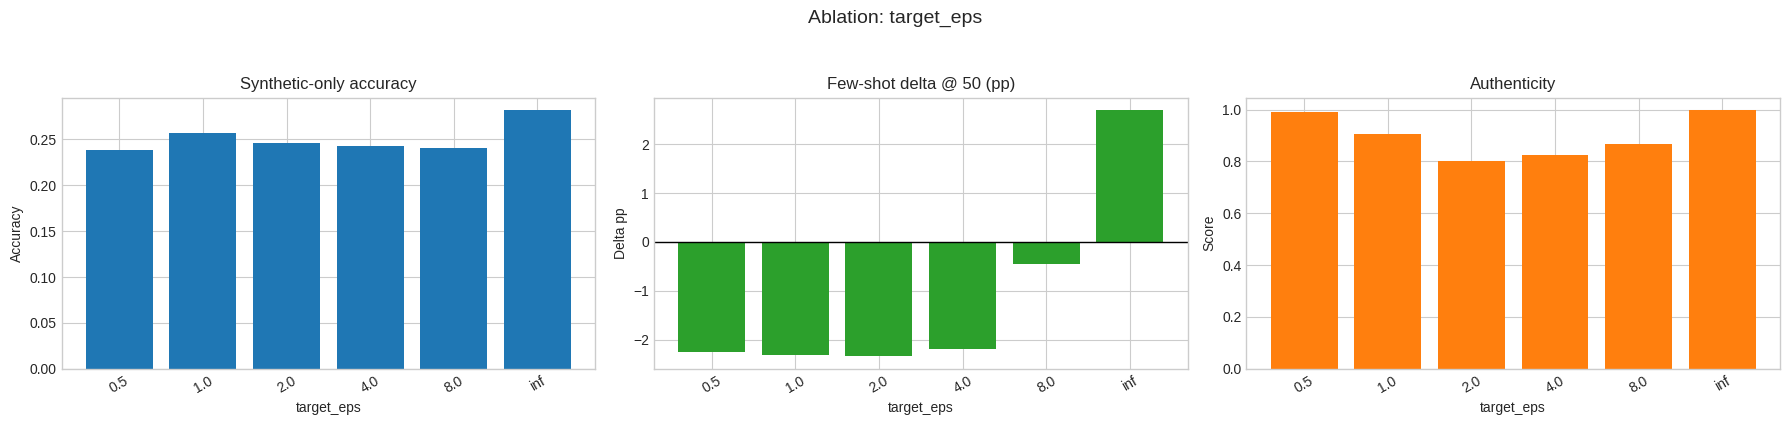

,axis_value_str,n_seeds,syn_only_acc_mean,delta_pp_50_mean,authenticity_mean,wall_time_s_mean
0,0.5,3,0.238233,-2.253333,0.988667,538.514305
1,1.0,3,0.256533,-2.326667,0.904167,519.077357
2,2.0,3,0.245867,-2.346667,0.803000,525.051959
3,4.0,3,0.242267,-2.186667,0.824333,522.584947
4,8.0,3,0.240467,-0.443333,0.868833,530.734062
5,inf,6,0.281517,2.703333,0.996417,158.292084


In [5]:
# target_eps
plot_axis("target_eps", "Ablation: target_eps")


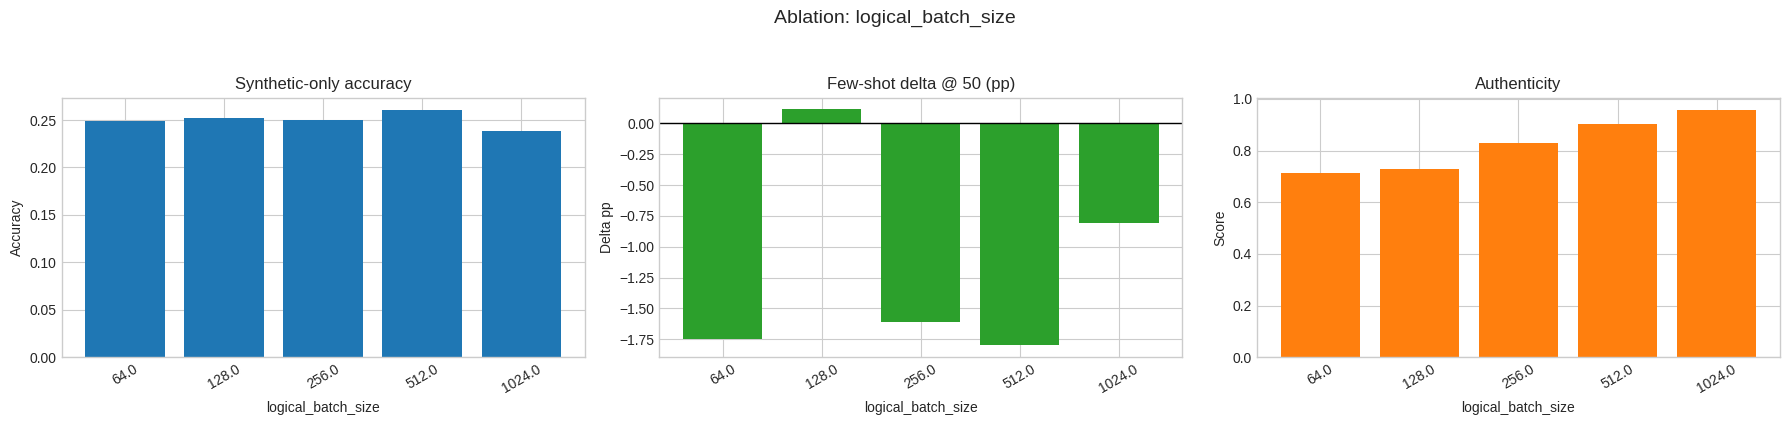

,axis_value_str,n_seeds,syn_only_acc_mean,delta_pp_50_mean,authenticity_mean,wall_time_s_mean
0,64.0,3,0.249400,-1.750000,0.714000,601.863786
1,128.0,3,0.252533,0.113333,0.729833,551.239708
2,256.0,3,0.249867,-1.610000,0.827833,537.009322
3,512.0,3,0.260733,-1.800000,0.904167,530.388070
4,1024.0,3,0.238667,-0.810000,0.957333,551.385528


In [6]:
# logical_batch_size
plot_axis("logical_batch_size", "Ablation: logical_batch_size")


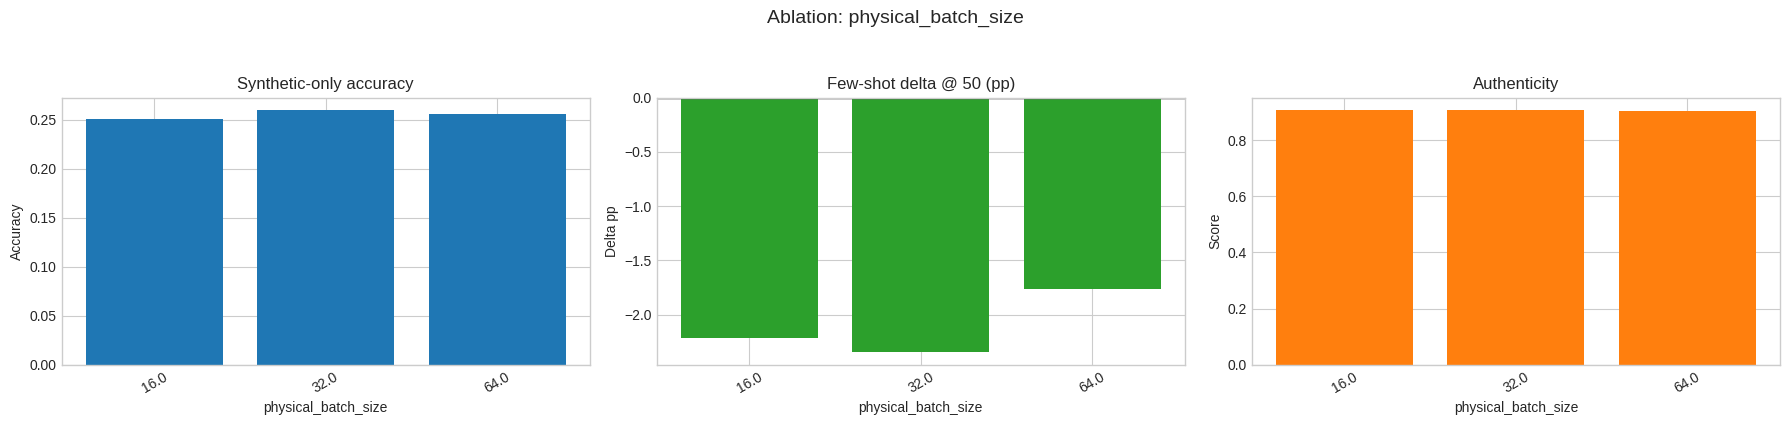

,axis_value_str,n_seeds,syn_only_acc_mean,delta_pp_50_mean,authenticity_mean,wall_time_s_mean
0,16.0,3,0.250967,-2.220000,0.906000,798.762634
1,32.0,3,0.259633,-2.346667,0.905667,616.500138
2,64.0,3,0.255600,-1.760000,0.904167,520.743070


In [7]:
# physical_batch_size
plot_axis("physical_batch_size", "Ablation: physical_batch_size")


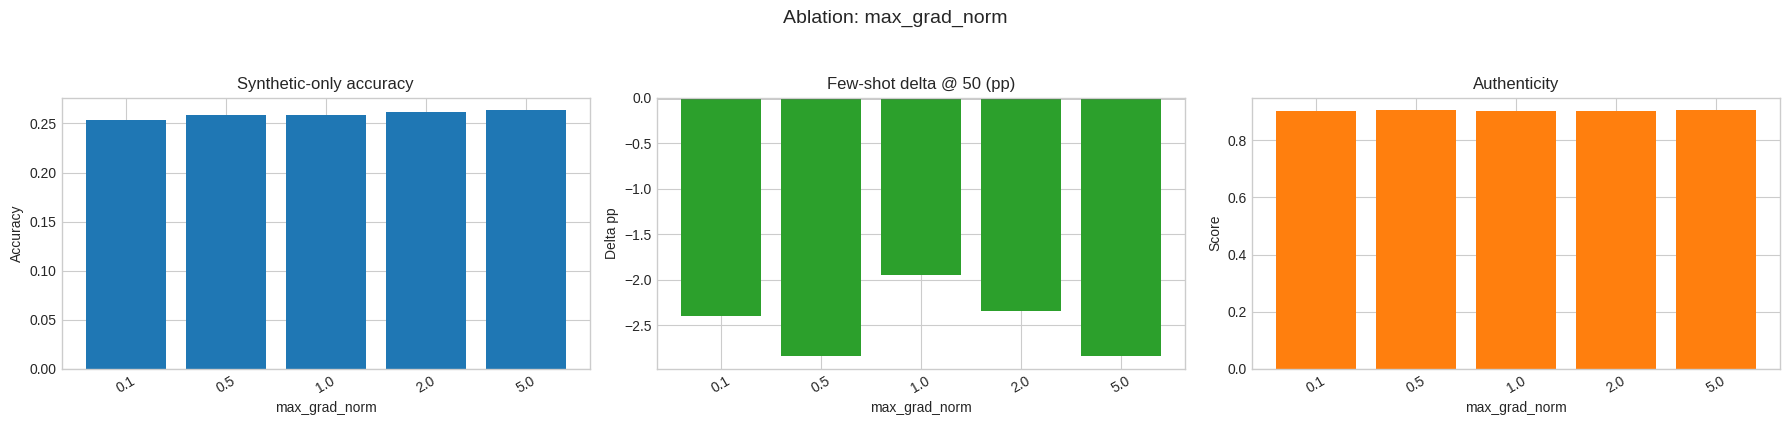

,axis_value_str,n_seeds,syn_only_acc_mean,delta_pp_50_mean,authenticity_mean,wall_time_s_mean
0,0.1,3,0.253133,-2.403333,0.904167,495.141275
1,0.5,3,0.258267,-2.836667,0.904667,494.729567
2,1.0,3,0.258767,-1.946667,0.904167,494.734274
3,2.0,3,0.261567,-2.343333,0.904500,495.092378
4,5.0,3,0.263267,-2.833333,0.904833,494.476907


In [8]:
# max_grad_norm
plot_axis("max_grad_norm", "Ablation: max_grad_norm")


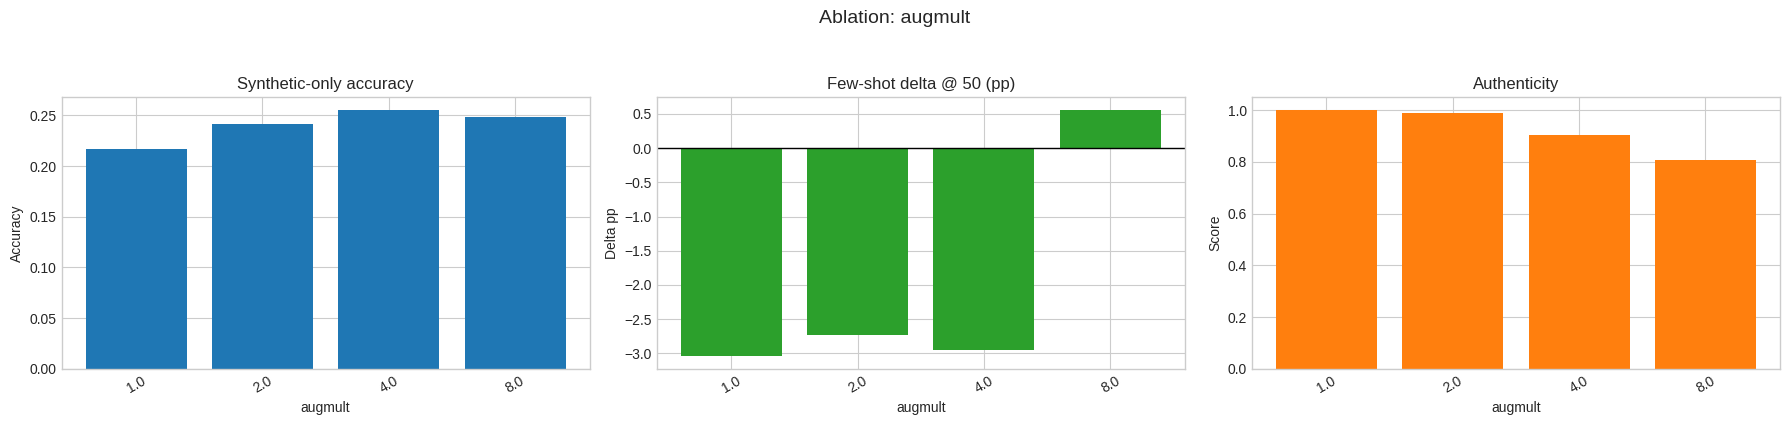

,axis_value_str,n_seeds,syn_only_acc_mean,delta_pp_50_mean,authenticity_mean,wall_time_s_mean
0,1.0,3,0.217000,-3.043333,0.999167,252.501058
1,2.0,3,0.241533,-2.733333,0.990333,321.718644
2,4.0,3,0.255133,-2.946667,0.904167,528.877522
3,8.0,3,0.248633,0.560000,0.806167,953.756056


In [9]:
# augmult
plot_axis("augmult", "Ablation: augmult")


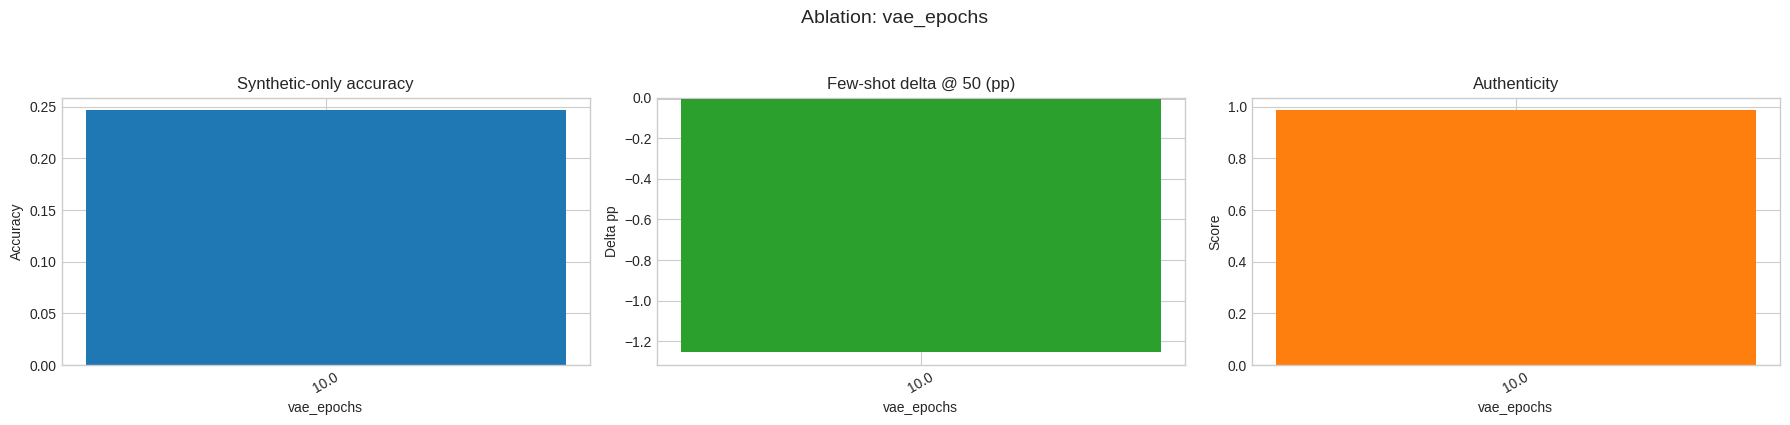

,axis_value_str,n_seeds,syn_only_acc_mean,delta_pp_50_mean,authenticity_mean,wall_time_s_mean
0,10.0,3,0.2467,-1.253333,0.986333,149.401896


In [10]:
# vae_epochs
plot_axis("vae_epochs", "Ablation: vae_epochs")


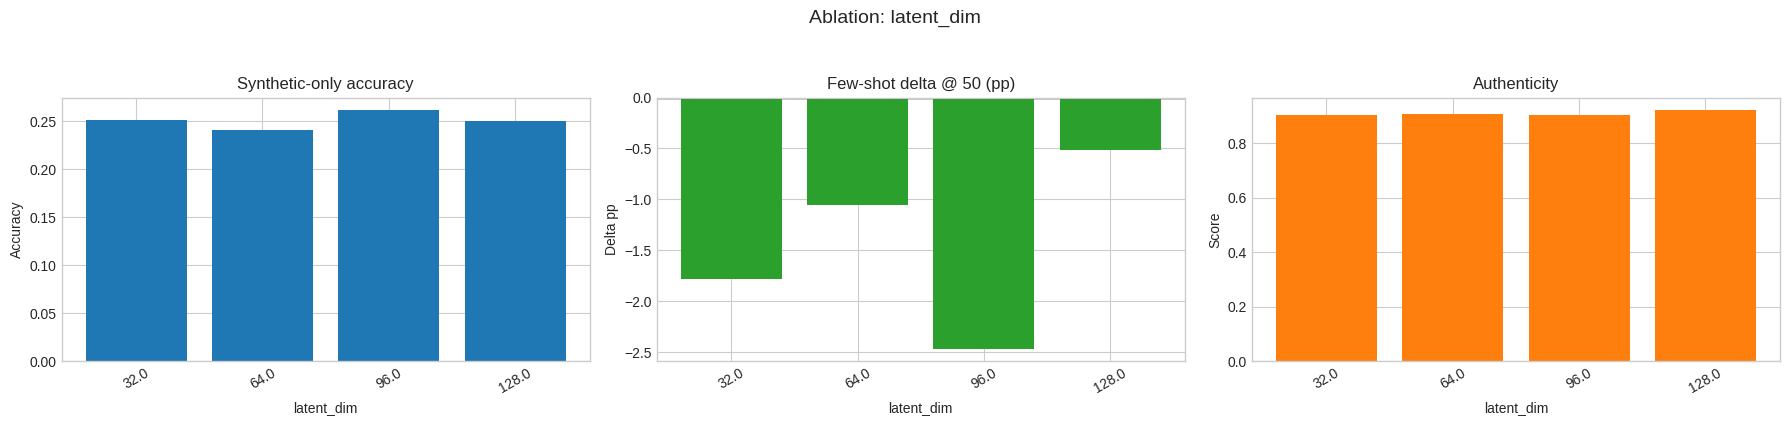

,axis_value_str,n_seeds,syn_only_acc_mean,delta_pp_50_mean,authenticity_mean,wall_time_s_mean
0,32.0,3,0.250667,-1.776667,0.902667,448.146664
1,64.0,3,0.240667,-1.050000,0.908000,473.151091
2,96.0,3,0.261467,-2.463333,0.904167,494.723432
3,128.0,3,0.250333,-0.513333,0.922333,518.732873


In [11]:
# latent_dim
plot_axis("latent_dim", "Ablation: latent_dim")


In [12]:
# vae_lr
plot_axis("vae_lr", "Ablation: vae_lr")


No data for axis: vae_lr
